In [2]:
import pandas as pd 
movies_data = pd.read_csv("../data/movies.csv")
ratings_data = pd.read_csv("../data/ratings.csv")
links_data = pd.read_csv("../data/links.csv")
tags_data = pd.read_csv("../data/tags.csv")
movies_df = movies_data.copy()
ratings_df = ratings_data.copy()


In [3]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [6]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [7]:
print(f"Nombre de films : {movies_df.shape[0]}")
print(f"Nombre de ratings : {ratings_df.shape[0]}")
print(f"Nombre d'utilisateurs : {ratings_df['userId'].nunique()}")
print(f"Note moyenne : {ratings_df['rating'].mean():.2f}")
print(f"Note médiane : {ratings_df['rating'].median():.2f}")


Nombre de films : 9742
Nombre de ratings : 100836
Nombre d'utilisateurs : 610
Note moyenne : 3.50
Note médiane : 3.50


In [8]:
print("\n=== DISTRIBUTION DES NOTES ===")
print(ratings_df['rating'].value_counts().sort_index())


=== DISTRIBUTION DES NOTES ===
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


<Axes: xlabel='rating'>

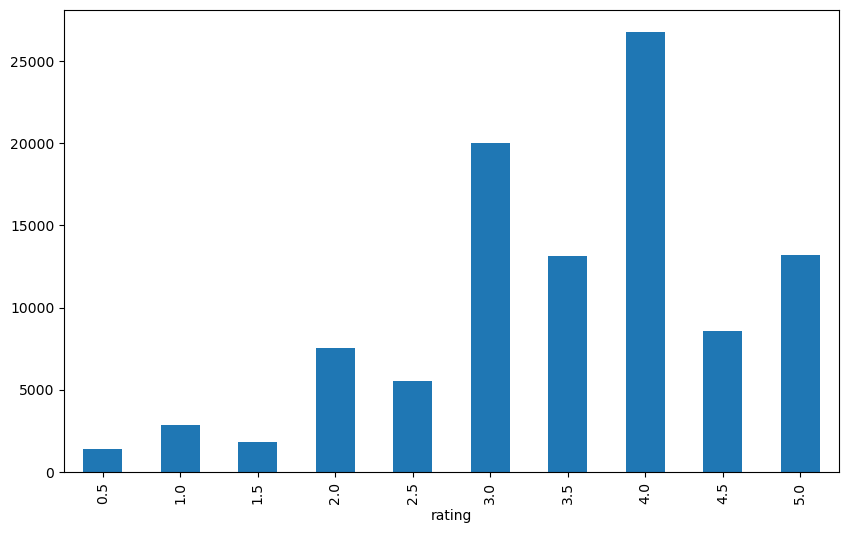

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
ratings_df['rating'].value_counts().sort_index().plot(kind='bar')

l'analyse de la distribution des notes nous montre qu'il y as plus de films ayant reçu des notes élevées, que de films avec des notes basses. les gens ont donc plus tendance à noter les films qu'ils ont aimés 

In [ ]:
sparsite = 1 - (ratings_df.shape[0] / (ratings_df['userId'].nunique() * movies_df.shape[0]))
print(f"Sparsité calculée manuellement : {sparsite:.2%}")

'''sparsite = ratings_df.pivot_table(index='userId', columns='movieId', values='rating')
print(f"Sparsite de la matrice utilisateur-film : {sparsite.isna().mean().mean():.2%}") 
NB : ce code est cependant à éviter car il peut être très gourmand en mémoire
 et en temps de calcul, surtout pour de grands datasets.'''

Sparsité calculée manuellement : 98.30%


'sparsite = ratings_df.pivot_table(index=\'userId\', columns=\'movieId\', values=\'rating\')\nprint(f"Sparsite de la matrice utilisateur-film : {sparsite.isna().mean().mean():.2%}") \nNB : ce code est cependant à éviter car il peut être très gourmand en mémoire\n et en temps de calcul, surtout pour de grands datasets.'

Avec une sparsité de 98.30 % de vide, on doit donc opter pour une stratégie de factorisation de matrice afin de résoudre le problème du cold start, dans le cadre de la recommandation basée sur le filtrage collaboratif

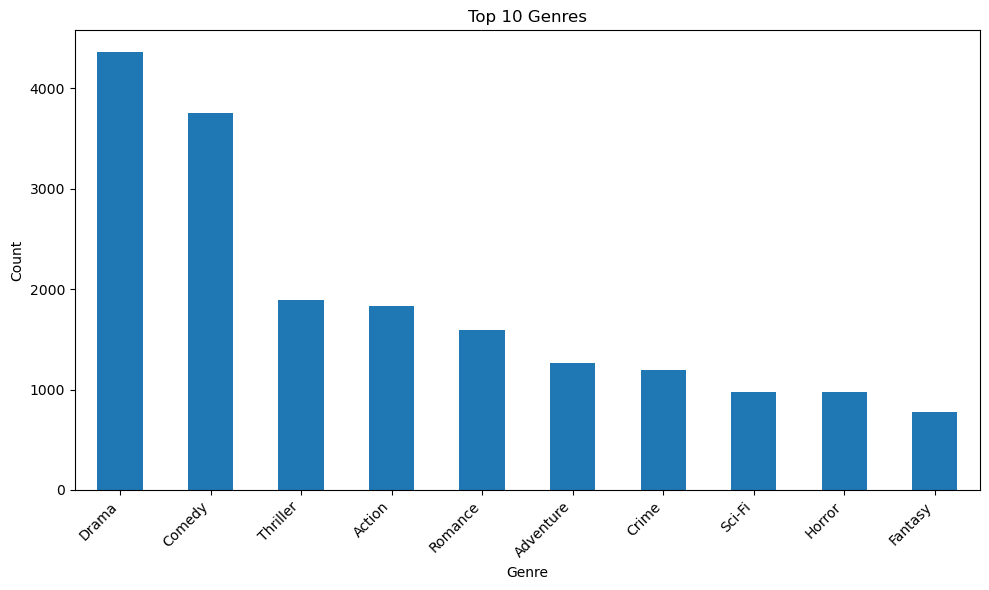

In [11]:
plt.figure(figsize=(10, 6))
movies_df['genres'].str.split('|').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

de l'analyse de ce graphique, les trois genres dominants sont : Drama, Comedy, et Trhiller

In [12]:
pourcentage_genre_dominanant = movies_df['genres'].str.split('|').explode().value_counts() / movies_df.shape[0]
print("pourcentage par genre :")
print(pourcentage_genre_dominanant.map('{:.2%}'.format))

pourcentage par genre :
genres
Drama                 44.76%
Comedy                38.55%
Thriller              19.44%
Action                18.76%
Romance               16.38%
Adventure             12.96%
Crime                 12.31%
Sci-Fi                10.06%
Horror                10.04%
Fantasy                8.00%
Children               6.82%
Animation              6.27%
Mystery                5.88%
Documentary            4.52%
War                    3.92%
Musical                3.43%
Western                1.71%
IMAX                   1.62%
Film-Noir              0.89%
(no genres listed)     0.35%
Name: count, dtype: object


Avec 44,76 %, notre catalogue est très déséquilibré. Si l'on  ne normalise pas, le système sera très bon pour prédire que les gens aiment le drame (ce qui est facile), mais très mauvais pour offrir une diversité pertinente.

QUESTION : Pour quelle stratégie de normalisation dois-je opter ? Avec la recommandation basée sur le contenu (content-based), ce problème est directement régler tant qu'on utilise la similarité cosinus.En ce qui concerne le filtrage colaboratif , il faudra : 
- ***Ajouter un penalty de diversité : si on  recommandes déjà 3 Dramas, on  boost les autres genres***
- ***faire un re-ranking : prendre top 20 films similaires, puis sélectionner 5 avec diversité de genres***

In [26]:
# 1. Calculer le nombre de notes ET la moyenne par film
stats_films = ratings_df.groupby('movieId')['rating'].agg(['count', 'mean'])

# 2. Filtrer : On ne garde que les films ayant au moins 100 notes (Seuil de crédibilité)
populaires_et_bons = stats_films[stats_films['count'] >= 100]

# 3. Trier par note moyenne et fusionner avec les titres
top_10_reel = populaires_et_bons.sort_values(by='mean', ascending=False).head(10)
top_10_reel = top_10_reel.reset_index().merge(movies_df[['movieId', 'title']], on='movieId')

print("Top 10 des films populaires les mieux notés :")
print(top_10_reel[['title', 'count', 'mean']])


Top 10 des films populaires les mieux notés :
                              title  count      mean
0  Shawshank Redemption, The (1994)    317  4.429022
1             Godfather, The (1972)    192  4.289062
2                 Fight Club (1999)    218  4.272936
3    Godfather: Part II, The (1974)    129  4.259690
4              Departed, The (2006)    107  4.252336
5                 Goodfellas (1990)    126  4.250000
6                 Casablanca (1942)    100  4.240000
7           Dark Knight, The (2008)    149  4.238255
8        Usual Suspects, The (1995)    204  4.237745
9        Princess Bride, The (1987)    142  4.232394


Les films les mieux notés sont éffectivement des blockbusters, le datatset réflète donc la réalité

In [27]:
nb_note_par_film = ratings_df.groupby('movieId').size()

films_cold_start = nb_note_par_film[nb_note_par_film < 5]

total_films = movies_df['movieId'].nunique()
nb_cold_start = len(films_cold_start)
pourcentage_cold_start = (nb_cold_start / total_films)

print(f"Nombre de films en Cold Start (< 5 notes) : {nb_cold_start}")
print(f"Pourcentage du catalogue concerné : {pourcentage_cold_start:.2%}")

films_avec_plus_de_20_notes = nb_note_par_film[nb_note_par_film > 20]
films_avec_plus_de_50_notes = nb_note_par_film[nb_note_par_film > 50]
print(f"Nombre de films avec plus de 50 notes : {len(films_avec_plus_de_50_notes)}")
films_avec_plus_de_100_notes = nb_note_par_film[nb_note_par_film > 100]
print(f"Nombre de films avec plus de 100 notes : {len(films_avec_plus_de_100_notes)}")
print(f"Pourcentage de films avec plus de 20 notes : {len(films_avec_plus_de_20_notes) / total_films:.2%}")
print(f"Pourcentage de films avec plus de 50 notes : {len(films_avec_plus_de_50_notes) / total_films:.2%}")
print(f"Pourcentage de films avec plus de 100 notes : {len(films_avec_plus_de_100_notes) / total_films:.2%}")


Nombre de films en Cold Start (< 5 notes) : 6074
Pourcentage du catalogue concerné : 62.35%
Nombre de films avec plus de 50 notes : 436
Nombre de films avec plus de 100 notes : 134
Pourcentage de films avec plus de 20 notes : 12.68%
Pourcentage de films avec plus de 50 notes : 4.48%
Pourcentage de films avec plus de 100 notes : 1.38%


on constate donc que 62.35% des films ont un nombre de notes en dessous de 5 . Par conséquent, le système de filtrage colaboratif , ne pourra pas faire de bonnes recommandations (ne fonctionnera réellemnt que sur 37% des films)

Par ailleurs , on constate qu'il y a 12.68 % de films avec plus de 20 notes,seulement 4.48% de films avec plus de 50 notes et 1.38% de films avec plus 100 notes 

Il faut donc penser à une aproche hybride: Si un film est en "Cold Start" (peu de notes), on ne regardes plus qui l'a noté, mais ce qu'il contient (ses genres). On compares alors ses genres avec les genres préférés de l'utilisateur. 
 

In [ ]:
user_activity = ratings_df.groupby('userId').size()
print(f"Nombre de film noté par utilisateur : {user_activity}")


Nombre de film noté par utilisateur : userId
1       232
2        29
3        39
4       216
5        44
       ... 
606    1115
607     187
608     831
609      37
610    1302
Length: 610, dtype: int64


In [18]:

print(f"Description du nombre de notes par utilisateur :\n{user_activity.describe()}")

Description du nombre de notes par utilisateur :
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


In [23]:
utilisateur_avec_plus_de_50_notes = user_activity[user_activity > 50]
print(f"Nombre d'utilisateurs avec plus de 50 notes : {len(utilisateur_avec_plus_de_50_notes)}")
utilisateur_avec_plus_de_100_notes = user_activity[user_activity >100]
print(f"Nombre d'utilisateurs avec plus de 100 notes : {len(utilisateur_avec_plus_de_100_notes)}")
print(f"Pourcentage des utilisateurs avec plus de 50 notes : {len(utilisateur_avec_plus_de_50_notes) / user_activity.shape[0]:.2%}")
print(f"Pourcentage des utilisateurs avec plus de 100 notes : {len(utilisateur_avec_plus_de_100_notes) / user_activity.shape[0]:.2%}")

Nombre d'utilisateurs avec plus de 50 notes : 378
Nombre d'utilisateurs avec plus de 100 notes : 245
Pourcentage des utilisateurs avec plus de 50 notes : 61.97%
Pourcentage des utilisateurs avec plus de 100 notes : 40.16%


le nombre minimum de films notés par utilisateurs est de 20 films; de plus on constate que 61.97% des utilisateurs ont attribué plus de 50 notes et 40.16% ont attribués plus de 100 notes. Par ailleurs, le nombre maximum de note atribué est de 2698 notes. 